In [1]:
import os
import requests
import json
from dotenv import load_dotenv
import requests_cache
import re
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer


C:\Users\123li\AppData\Local\Temp\ipykernel_20468\2461324362.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# set up a cached session
session = requests_cache.CachedSession('output/steam_api_cache', expire_after=86400)

In [3]:
# convert the steam_1000.jsonl to dataframe
def clean_html(text):
    if not isinstance(text, str):
        return ""
    # remove HTML tags like <>, <b>, etc.
    return re.sub(r'<.*?>', '', text)

def flatten_list(items):
    # this is to extract items from the internal list as new columns 
    if isinstance(items, list):
        # extract the description field and join with commas 
        return ", ".join(item.get("description", "") for item in items)
    return ""

raw_data = []
# load the JSONL file into a list
with open("steam_1000.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        raw_data.append(json.loads(line))

# convert to DataFrame, flattening the lists
df = pd.json_normalize(raw_data)

# deal with complex list features 
df['genres(cleaned)'] = df['genres'].apply(flatten_list)
df['categories(cleaned)'] = df['categories'].apply(flatten_list)


# clean HTML from description column
text_cols = ['detailed_description', 'short_description', 'about_the_game', 'supported_languages',
             'pc_requirements.minimum', 'pc_requirements.recommended', 
             'mac_requirements.minimum', 'mac_requirements.recommended',
             'linux_requirements.minimum', 'linux_requirements.recommended']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_html)

# price in the original data is represented in cents
# convert it to get the dollar format, NaN remains NaN in this step
if 'price_overview.initial' in df.columns:
    df['price_overview.initial'] = df['price_overview.initial'] / 100

if 'price_overview.final' in df.columns:
    df['price_overview.final'] = df['price_overview.final'] / 100

# summarize and select(rename) the cleaned columns we need to form the final data frame
final_columns = ['name', 'steam_appid', 'type', 'is_free', 'developers', 'publishers', 
                 'detailed_description', 'short_description', 'about_the_game', 'supported_languages',
                 'pc_requirements.minimum', 'pc_requirements.recommended', 
                 'mac_requirements.minimum', 'mac_requirements.recommended',
                 'linux_requirements.minimum', 'linux_requirements.recommended',
                 'genres(cleaned)', 'categories(cleaned)',
                 'price_overview.currency', 'price_overview.initial', 'price_overview.final', 'price_overview.discount_percent', 
                 'platforms.windows', 'platforms.mac', 'platforms.linux', 
                 'packages', 'recommendations.total', 'release_date.date'
    ]

df_final = pd.DataFrame(df[[c for c in final_columns if c in df.columns]])
print("Final DataFrame shape:", df_final.shape)
print("\nThe first 5 rows of the final DataFrame:")
print(df_final.head())


Final DataFrame shape: (1000, 28)

The first 5 rows of the final DataFrame:
                                 name  steam_appid  type  is_free  \
0           Saints Row IV: Re-Elected       206420  game    False   
1  ARMORED CORE™ VI FIRES OF RUBICON™      1888160  game    False   
2   Tavern Talk - A Cozy Visual Novel      2076140  game    False   
3       Graviteam Tactics: Mius-Front       312980  game    False   
4                    SONIC SUPERSTARS      2022670  game    False   

                     developers  \
0        [Deep Silver Volition]   
1          [FromSoftware, Inc.]   
2  [Gentle Troll Entertainment]   
3                   [Graviteam]   
4                        [SEGA]   

                                          publishers  \
0                                      [Deep Silver]   
1  [FromSoftware, Inc., Bandai Namco Entertainmen...   
2                       [Gentle Troll Entertainment]   
3                                        [Graviteam]   
4                 

In [4]:
# get the dataset summary information
print("Dataset Summary:")
print(df_final.info())

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name                             1000 non-null   object 
 1   steam_appid                      1000 non-null   int64  
 2   type                             1000 non-null   object 
 3   is_free                          1000 non-null   bool   
 4   developers                       1000 non-null   object 
 5   publishers                       999 non-null    object 
 6   detailed_description             1000 non-null   object 
 7   short_description                1000 non-null   object 
 8   about_the_game                   1000 non-null   object 
 9   supported_languages              1000 non-null   object 
 10  pc_requirements.minimum          1000 non-null   object 
 11  pc_requirements.recommended      1000 non-null   object 
 12  mac_

 ### Question 2:  
 How do textual features and player sentiments in game reviews differ between high-selling and low-selling games, and what are the key drivers of positive and negative feedback for games?  
 
 Specifically, We applied Natural Language Processing (NLP) techniques, specifically TF-IDF (Term Frequency-Inverse Document Frequency) to analyze the text of the reviews and also perform a comparative analysis of the differences and sentiment drivers in top-sellers vs. low-sellers games. 
 

In [5]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
}

In [ ]:
"""
# fetch the first 100 reviews for a given steam appid
# more than 100 reviews might get banned
def fetch_reviews(appid, num_per_page=100):
    url = f"https://store.steampowered.com/appreviews/{appid}"
    params = {
        'json': 1, # means return json format
        'filter': 'all', # get all the historical reviews (not only recent), usually ordered by the most valued reviews
        'language': 'english', # only get the English reviews
        'num_per_page': num_per_page, # set the max to 100 reviews 
        'day_range': 9223372036854775807, # this is the maximum value of 64-bit signed integer(standard representation for all time) to get all the reviews from the past
        'review_type': 'all', # get all types of reviews (including positive and negative)
        'purchase_type': 'all', # get all types of purchased reviews
        'cursor': '*' # * means start from the beginning
    }
    try:
        response = requests.get(url=url, params=params, headers=headers, timeout=20)

        if response.status_code == 429:
            print(f"Rate limited on appid: {appid}, sleeping...")
            time.sleep(60) # sleep for 60 seconds
            return fetch_reviews(appid, num_per_page) # retry the request
        
        data = response.json()
        if data.get("success") and "reviews" in data:
            return data["reviews"]
        return None
    
    except Exception as e:
        print(f"Error fetching reviews for appid: {appid}, error: {e}")
        return None
    
# get the appids from df_final
appids = df_final['steam_appid'].unique().tolist()

out_file = "reviews_1000.jsonl"
count = 0

# iterate over each appid and fetch the first 100 reviews for this game
# store them into the reviews_1000 json file
with open(out_file, "w", encoding="utf-8") as f:
    for appid in appids:
        reviews = fetch_reviews(appid)

        if reviews:
            for r in reviews:
                # save each review as a separate line with its appid
                clean_text = r.get('review', '').replace('\n', ' ').replace('\r', ' ').strip()

                review = {
                    "appid": int(appid),
                    # get the review text
                    "review": clean_text,
                    # get the information on whether the reviewer recommended or not (true or false)
                    'voted_up': r.get('voted_up'),
                    # get the number of upvotes
                    # means how many people think this reviews helpful, consider increasing the weight of the review
                    'votes_up': r.get('votes_up'), 
                    # get the number of downvotes, means how many people think this reviews not helpful
                    'votes_down': r.get('votes_down'),
                    # get the playtime at review, the number of hours that the reviewer play this game
                    'playtime_at_review': r.get('author', {}).get('playtime_at_review'), 
                    # total playtime of this reviewer until now
                    'playtime_forever': r.get('author', {}).get('playtime_forever'), 
                    # bool: whether the reviewer received the game for free
                    'received_for_free': r.get('received_for_free'), 
                    'comment_count': r.get('comment_count'), 
                    # a credibility score between 0 and 1, calulated based on the votes_up and publish time
                    'weighted_vote_score': r.get('weighted_vote_score')
                }
                f.write(json.dumps(review) + "\n")          
            count += 1
            if count % 50 == 0:
                print(f"Processed and saved {count}/{len(appids)} games.")

        # slow down the fetch, use random to avoid being identify as robot, avoid blocked
        # approx 3-4 seconds of sleep
        time.sleep(3+random.random())

print(f"Finished processing all the reviews for games. Total saved: {count}")

"""

Processed and saved 50/1000 games.
Processed and saved 100/1000 games.
Processed and saved 150/1000 games.
Processed and saved 200/1000 games.
Processed and saved 250/1000 games.
Processed and saved 300/1000 games.
Processed and saved 350/1000 games.
Processed and saved 400/1000 games.
Processed and saved 450/1000 games.


In [6]:
# load the review data in the dataframe
df_reviews = pd.read_json('reviews_1000.jsonl', lines=True)

# basic information of the data and get a overall summary statistics
print(f"The shape of the DataFrame is: {df_reviews.shape[0]} rows and {df_reviews.shape[1]} columns")
# print how many games are in the data
print(f"Number of unique games: {df_reviews['appid'].nunique()}")
print("\n")
print(df_reviews.info())
print("\n")
print(df_reviews.head())

The shape of the DataFrame is: 98038 rows and 10 columns
Number of unique games: 992


<class 'pandas.core.frame.DataFrame'>
Index: 98038 entries, 0 to 98037
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                98038 non-null  int64  
 1   review               98038 non-null  object 
 2   voted_up             98038 non-null  bool   
 3   votes_up             98038 non-null  int64  
 4   votes_down           0 non-null      float64
 5   playtime_at_review   97730 non-null  float64
 6   playtime_forever     98038 non-null  int64  
 7   received_for_free    98038 non-null  bool   
 8   comment_count        98038 non-null  int64  
 9   weighted_vote_score  98038 non-null  float64
dtypes: bool(2), float64(3), int64(4), object(1)
memory usage: 6.9+ MB
None


    appid                                             review  voted_up  \
0  206420  How to play SR4 without needing to get the ♥♥♥

In [7]:
# data cleanning
df_reviews = df_reviews.drop_duplicates()

# convert playtime from minutes into the unit of hour
df_reviews['playtime_at_review_hrs'] = df_reviews['playtime_at_review'] / 60
df_reviews['playtime_forever_hrs'] = df_reviews['playtime_forever'] / 60

# rename voted_up and redefine the value
# use this value as the criteria of positive sentiment or negative sentiment
df_reviews['sentiment'] = df_reviews['voted_up'].map({True: 'Positive', False: 'Negative'})

# votes_down already drop because the value is all null
df_reviews = df_reviews.drop(columns=['votes_down'], errors='ignore')

# remove the old columns
cols_to_drop = ['voted_up', 'playtime_at_review', 'playtime_forever']
df_reviews = df_reviews.drop(columns=cols_to_drop, errors='ignore') # is already drop, then ignore the error


In [8]:
print(f"The shape of the cleaned DataFrame is: {df_reviews.shape}")
print(f"The first five rows of the final data: {df_reviews.head()}")
print("\n")
print(df_reviews.describe())

The shape of the cleaned DataFrame is: (98038, 9)
The first five rows of the final data:     appid                                             review  votes_up  \
0  206420  How to play SR4 without needing to get the ♥♥♥...       394   
1  206420  Right click Saints Row IV in your Library, Pro...       104   
2  206420  This game is awesome for a main reason : bunch...       161   
3  206420  Bait and switch of a game.  I bought a steam g...       134   
4  206420  >"Free Upgrade" to Saints Row 4 that adds cros...      1747   

   received_for_free  comment_count  weighted_vote_score  \
0              False              5             0.946757   
1              False              5             0.903494   
2              False              0             0.928132   
3              False              0             0.862995   
4              False             62             0.960121   

   playtime_at_review_hrs  playtime_forever_hrs sentiment  
0               42.916667             43.9833

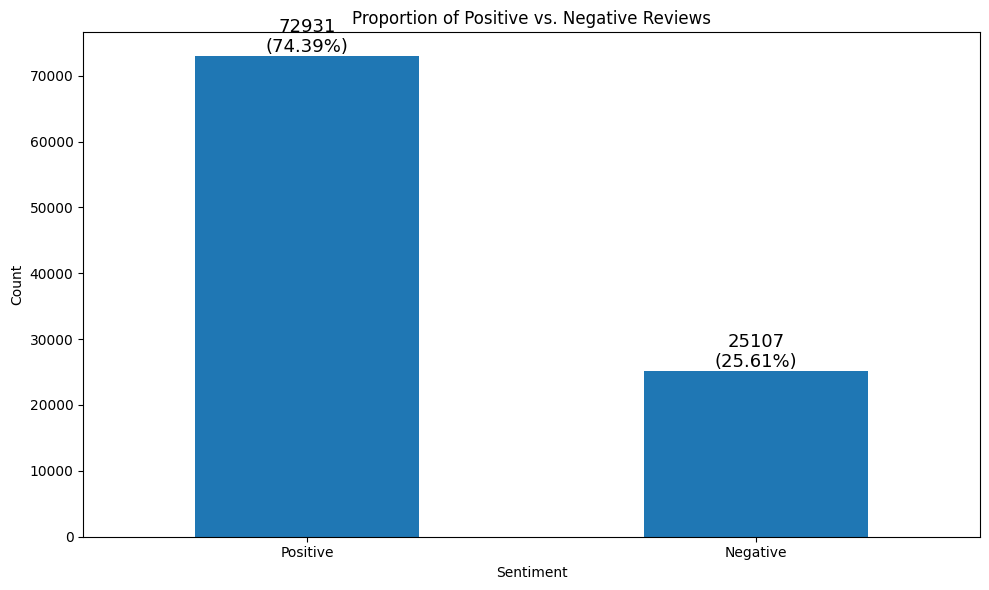

In [9]:
# visualizations
# 1. proportion of positive reviews vs. negative reviews
total_count = len(df_reviews)

# Create a bar plot with corresponding labels
sentiment_counts = df_reviews['sentiment'].value_counts()
ax = sentiment_counts.plot(kind='bar', figsize=(10, 6), rot=0)

# Add value labels on top of bars with pos/neg count and percentage
for i, (sentiment, count) in enumerate(sentiment_counts.items()):
    percent = count / total_count * 100
    ax.text(i, count, f'{count}\n({percent:.2f}%)', ha='center', va='bottom', fontsize=13)

plt.title('Proportion of Positive vs. Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
medians = df_reviews.groupby('sentiment')['playtime_at_review_hrs'].median()

print("--- Median Playtime (at Review) ---")
print(f"Positive: {medians['Positive']:.2f} hours")
print(f"Negative: {medians['Negative']:.2f} hours")
# the median hours for positive review is larger than the negative reviews, 
# means that positive reviewers tend to play the game for a longer time at the time of their review.

--- Median Playtime (at Review) ---
Positive: 17.75 hours
Negative: 13.36 hours


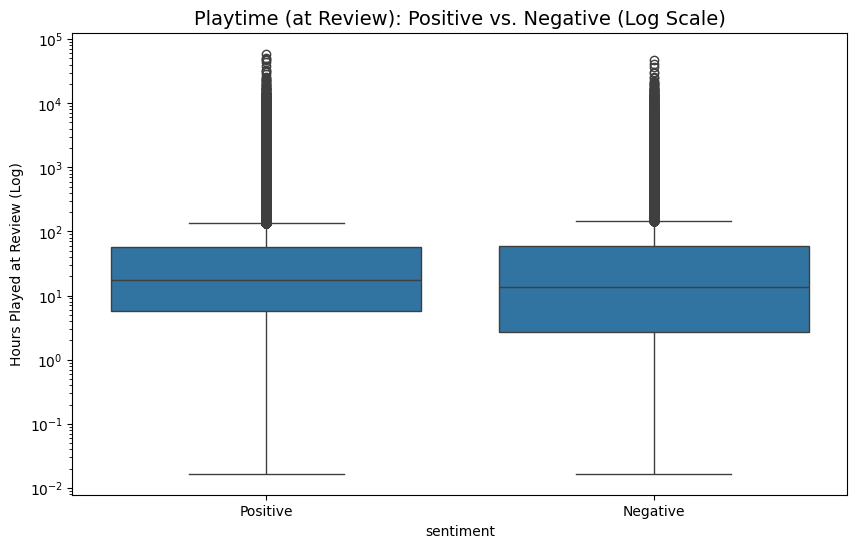

In [11]:
# 2. The playtime distribution for both sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='playtime_at_review_hrs', data=df_reviews)
plt.yscale('log') # using log because the time difference is large between reviewers
plt.title('Playtime (at Review): Positive vs. Negative (Log Scale)', fontsize=14)
plt.ylabel('Hours Played at Review (Log)')
plt.show()

# from the boxplot, we know that most reviewer are giving reviews at around few hours to 100 hours.
# this suggests that the majority of reviewers have played the game for a moderate amount of time before writing their reviews.

# the whiskers are longer at the negative end, means that there are some reviewers giving reviews at the very first hours of their playing.

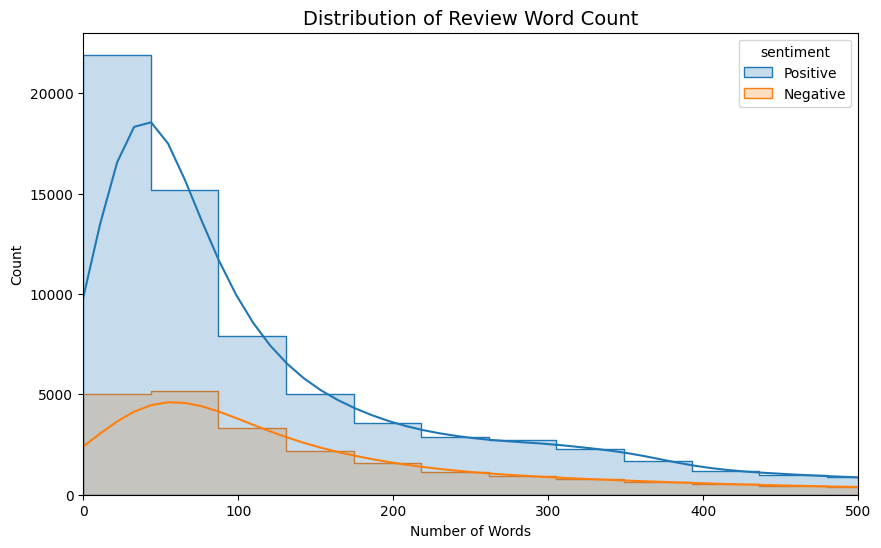

In [12]:
# 3. Distribution of word count for positive review and negative review
# calculate the number of words for each review
df_reviews['word_count'] = df_reviews['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df_reviews, x='word_count', hue='sentiment', bins=50, kde=True, element="step")
plt.xlim(0, 500)
plt.title('Distribution of Review Word Count', fontsize=14)
plt.xlabel('Number of Words')
plt.show()

# reviews are mostly short for both positive and negative sentiment.

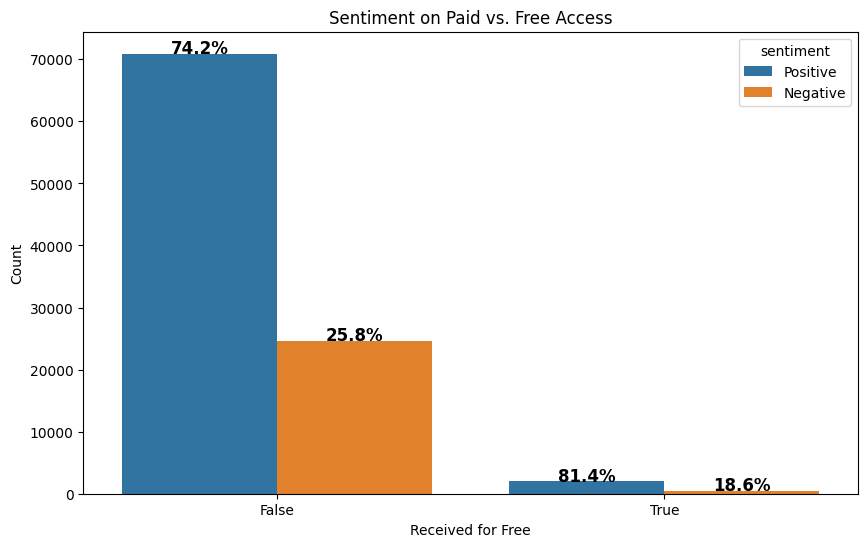

In [13]:
# 4. proportion of positive/negative reviews on free vs. paid access
# Calculate proportions for received_for_free = False
paid_total = (df_reviews['received_for_free'] == False).sum()
paid_positive = ((df_reviews['received_for_free'] == False) & (df_reviews['sentiment'] == 'Positive')).sum()
paid_negative = paid_total - paid_positive
paid_pos_pct = paid_positive / paid_total * 100
paid_neg_pct = paid_negative / paid_total * 100

# Calculate proportions for received_for_free = True
free_total = (df_reviews['received_for_free'] == True).sum()
free_positive = ((df_reviews['received_for_free'] == True) & (df_reviews['sentiment'] == 'Positive')).sum()
free_negative = free_total - free_positive
free_pos_pct = free_positive / free_total * 100
free_neg_pct = free_negative / free_total * 100

# Create bar plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='received_for_free', hue='sentiment', data=df_reviews)
plt.title('Sentiment on Paid vs. Free Access')
plt.xlabel('Received for Free')
plt.ylabel('Count')

# Add percentage labels on top of bars - check x position to determine which group
for patch in ax.patches:
    height = patch.get_height()
    if height == 0:
         continue
    # only add labels for the bars that have non-zero height
    x_pos = patch.get_x() + patch.get_width()/2.
    
    # Determine which group (False=0, True=1) based on x position
    if x_pos < 0.5:  # False (Paid) group
        if abs(height - paid_positive) < 1:
             label = f'{paid_pos_pct:.1f}%'
        else:
             label = f'{paid_neg_pct:.1f}%'
    else:  # True (Free) group
        if abs(height - free_positive) < 1:
             label = f'{free_pos_pct:.1f}%'
        else:
             label = f'{free_neg_pct:.1f}%'
    
    ax.text(x_pos, height, label, ha='center', fontsize=12, fontweight='bold')

plt.show()

In [14]:
stop_words = set(stopwords.words('english'))
print("stopwords: \n")
print(stop_words)

stopwords: 

{'me', 'off', 'they', "shouldn't", 'her', 'y', 'theirs', 'down', 'their', 'during', 'he', 'own', "we'd", "couldn't", 'into', 'shouldn', 'after', 'yourselves', 'there', 'whom', 'on', 'too', 'its', "she'd", 'that', 'are', "they're", "they'll", 'do', 'i', 'mustn', 'them', 'under', "mightn't", 'you', 'be', 'your', 't', "needn't", 'until', 'weren', "he'd", "haven't", "won't", 'some', 'has', 'it', 'by', 'itself', "mustn't", "you're", 'with', "didn't", 'only', 'then', "we're", 's', 'most', "i've", 're', 'while', 'herself', 'wouldn', "aren't", 'at', 'haven', 'hers', "that'll", 'no', 'yours', 'any', 'my', 'ours', 'each', 'this', "he's", "don't", "wouldn't", 'over', "hasn't", "it'll", 'myself', 'out', 'our', "doesn't", 'needn', 'other', 'is', 'a', 'hasn', 'isn', "he'll", "we've", 'll', "should've", 'because', "she's", 'very', 'against', 'but', 'm', "isn't", 'than', 'now', 'above', 'the', 'where', 'doing', 'when', 'didn', "hadn't", 'about', "you've", 've', 'further', 'shan', "i'm", '

In [15]:
# preprocessing review text (Text Cleaning)

# remove the unicode, unmeningful signs, and emoji in the text, only keep the english words
# remove the stopwords using the stopwords.words() and add some other stopwords for games (like play, game, steam)
other_stopwords = {'play', 'played', 'playing', 'game', 'games', 'steam', 'much', 'even', 'get'}
stop_words.update(other_stopwords)
important_words = {'not', 'no', 'against', 'neither', 'how'}
stop_words = stop_words - important_words

# after running the TF-IDF, I found that the output words have a lot of noise (Domain-specific Noise). 
# So I need to list these domain-specific words to clean it before running
domain_specific_noise = {'like', 'good', 'really', 'great', 'best', 'make', 'gets', 'getting', 
                         'want', 'wants', 'makes', 'making', 'made', 'likes', 'player', 
                         'players', 'people', 'fun', 'way', 'get', 'feel', 'feels','feeling', 
                         'feelings', 'think', 'love', 'bad', 'better', 'think', 'thought',
                         'know', 'recommend', 'even', 'little', 'bit', 'lot', 'nice', 'use', 'using', 
                         'say', 'got', 'definitely', 'need', 'going', 'need', 'time', 'thing', 'things', 
                         'times', 'year', 'years', 'hours', 'new', 'buy', 'brought', 'right', 'actually'}
stop_words.update(domain_specific_noise)

def clean_text(text):
    # instead of removing all the different emoji, signs
    # keep the english letters only (words only)
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))

    words = text.lower().split()

    # remove the stopwords and only remove if the text has more than 2 words
    no_stopwords = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(no_stopwords)

df_reviews['review_clean'] = df_reviews['review'].apply(clean_text)
df_reviews

,appid,review,votes_up,received_for_free,comment_count,weighted_vote_score,playtime_at_review_hrs,playtime_forever_hrs,sentiment,word_count,review_clean
0,206420,How to play SR4 without needing to get the ♥♥♥...,394,False,5,0.946757,42.916667,43.983333,Positive,70,how without needing platform epic step click l...
1,206420,"Right click Saints Row IV in your Library, Pro...",104,False,5,0.903494,80.666667,83.950000,Negative,30,click saints row library properties betas beta...
2,206420,This game is awesome for a main reason : bunch...,161,False,0,0.928132,33.666667,49.066667,Positive,89,awesome main reason bunch references many port...
3,206420,Bait and switch of a game. I bought a steam g...,134,False,0,0.862995,46.233333,46.233333,Negative,39,bait switch bought well corpos volition decide...
4,206420,">""Free Upgrade"" to Saints Row 4 that adds cros...",1747,False,62,0.960121,57.916667,85.300000,Negative,50,free upgrade saints row adds crossplay support...
...,...,...,...,...,...,...,...,...,...,...,...
98033,1281040,This game is so far removed from what anyone e...,3,False,0,0.540390,4.250000,5.100000,Positive,154,far removed anyone else worth experiencing dar...
98034,1281040,There is a thin line between being difficult a...,3,False,0,0.540193,12.800000,13.350000,Negative,266,thin line difficult difficult enjoy baby steps...
98035,1281040,"Hidden gem. Loved this game, all the dialogues...",3,False,0,0.536878,12.000000,12.350000,Positive,37,hidden gem loved dialogues deep meaning messag...
98036,1281040,Exploration is fun and there's a real sense of...,2,False,0,0.534884,5.683333,6.666667,Positive,19,exploration real sense accomplishment small ar...


sales_level
Medium-selling    458
High-selling      271
Low-selling       271
Name: count, dtype: int64
(98038, 16)

Review Distribution:
High-Pos: 22112, High-Neg: 4986
Low-Pos: 19104, Low-Neg: 7867

Proportion of Reviews:
Sentiment      Positive   Negative
High-selling  81.600118  18.399882
Low-selling   70.831634  29.168366


<Figure size 1000x600 with 0 Axes>

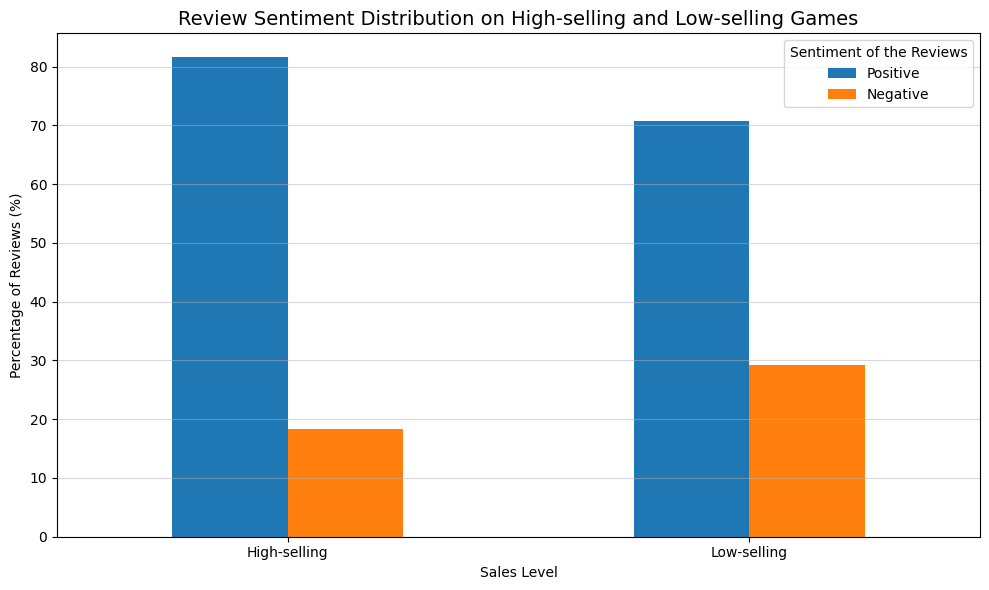

In [16]:
# Define High-selling as the top 30% of the recommendation.total
# Define Low-selling as the bottom 30% of the recommendation.total
high = df_final['recommendations.total'].quantile(0.7)
low = df_final['recommendations.total'].quantile(0.3)

# define a function to categorize products
def recommend_category(row):
    if row['recommendations.total'] >= high:
        return 'High-selling'
    elif row['recommendations.total'] <= low:
        return 'Low-selling'
    else:
        return 'Medium-selling'
df_final['sales_level'] = df_final.apply(recommend_category, axis=1)
print(df_final['sales_level'].value_counts())
# since there is only 904 not null value in recommendations.total

# use merge to link two df
# add the label columns to df_reviews based on the appid
df = pd.merge(df_reviews,
              df_final[['name', 'steam_appid', 'sales_level', 'recommendations.total', 'genres(cleaned)']],
              left_on='appid',
              right_on='steam_appid',
              how='inner'
)
print(df.shape)

# to compare the textual features, we divided the df into four df, pos/neg reviews in high/low selling games
# positive reviews in high-selling games
df_pos_high = df[(df['sales_level'] == 'High-selling') & (df['sentiment'] == 'Positive')]
# negative reviews in high-selling games
df_neg_high = df[(df['sales_level'] == 'High-selling') & (df['sentiment'] == 'Negative')]
# positive reviews in low-selling games
df_pos_low = df[(df['sales_level'] == 'Low-selling') & (df['sentiment'] == 'Positive')]
# negative reviews in low-selling games 
df_neg_low = df[(df['sales_level'] == 'Low-selling') & (df['sentiment'] == 'Negative')]
print("\nReview Distribution:")
print(f"High-Pos: {len(df_pos_high)}, High-Neg: {len(df_neg_high)}")
print(f"Low-Pos: {len(df_pos_low)}, Low-Neg: {len(df_neg_low)}")

# proportion of positive reviews and negative reviews in high-selling games
high_total = len(df_pos_high) + len(df_neg_high)
high_pos_pct = (len(df_pos_high) / high_total) * 100
high_neg_pct = (len(df_neg_high) / high_total) * 100

# proportion of positive reviews and negative reviews in low-selling games
low_total = len(df_pos_low) + len(df_neg_low)
low_pos_pct = (len(df_pos_low) / low_total) * 100
low_neg_pct = (len(df_neg_low) / low_total) * 100

# visualization on the proportion for two groups of games
# perpare the data for plotting
plot_data = pd.DataFrame({
    'Sentiment': ['Positive', 'Negative'],
    'High-selling': [high_pos_pct, high_neg_pct],
    'Low-selling': [low_pos_pct, low_neg_pct]
}).set_index('Sentiment').T
print("\nProportion of Reviews:")
print(plot_data)

# show the comparison of both positive and negative
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Review Sentiment Distribution on High-selling and Low-selling Games', fontsize=14)
plt.xlabel('Sales Level')
plt.ylabel('Percentage of Reviews (%)')
plt.legend(title='Sentiment of the Reviews')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Apply TF-IDF on four subset of reviews (Unsupervised Feature Extraction/Text Mining)

# filter out the words that occur more than 80% of the time
# filter out the words that occur less than 10 times
# only get the top 1000 features, top 1000 importance words
tfidf = TfidfVectorizer(max_features=1000, max_df=0.8, min_df=10, stop_words='english')
tfidf.fit(df['review_clean'])

df_pos_high_tfidf = tfidf.transform(df_pos_high['review_clean'])
df_neg_high_tfidf = tfidf.transform(df_neg_high['review_clean'])
df_pos_low_tfidf = tfidf.transform(df_pos_low['review_clean'])
df_neg_low_tfidf = tfidf.transform(df_neg_low['review_clean'])

# get the top 20 words from each subset
def top_20_words(matrix):
    feature_names = tfidf.get_feature_names_out()
    # calculate the mean TF-IDF score for each feature
    mean_tfidf = matrix.mean(axis=0).tolist()[0]

    # match each feature word with its average TF-IDF score and sort
    word_scores = sorted(zip(feature_names, mean_tfidf), key=lambda x: x[1], reverse=True)
    return [f"{word} ({score:.4f})" for word, score in word_scores[:20]]

top_pos_high = top_20_words(df_pos_high_tfidf)
top_neg_high = top_20_words(df_neg_high_tfidf)
top_pos_low = top_20_words(df_pos_low_tfidf)
top_neg_low = top_20_words(df_neg_low_tfidf)

df_comparison = pd.DataFrame({
    'High_Sales_Positive': top_pos_high,
    'High_Sales_Negative': top_neg_high,
    'Low_Sales_Positive': top_pos_low,
    'Low_Sales_Negative': top_neg_low
})
pd.options.display.float_format = '{:.4f}'.format
print(df_comparison)

    High_Sales_Positive High_Sales_Negative   Low_Sales_Positive  \
0        story (0.0376)        dlc (0.0346)       story (0.0229)   
1     gameplay (0.0248)    content (0.0269)    gameplay (0.0193)   
2         life (0.0243)      money (0.0255)      pretty (0.0188)   
3      friends (0.0235)     update (0.0255)       worth (0.0185)   
4         long (0.0220)     online (0.0239)         far (0.0179)   
5   experience (0.0209)     review (0.0203)     friends (0.0158)   
6        world (0.0204)       devs (0.0194)  characters (0.0156)   
7         bugs (0.0186)        fix (0.0190)     amazing (0.0154)   
8         hard (0.0182)     issues (0.0187)  experience (0.0151)   
9        grind (0.0176)      price (0.0183)   different (0.0147)   
10     amazing (0.0174)    release (0.0182)     content (0.0145)   
11       worth (0.0174)     single (0.0179)       early (0.0142)   
12     average (0.0166)   gameplay (0.0172)     overall (0.0140)   
13        easy (0.0165)  community (0.0171)     

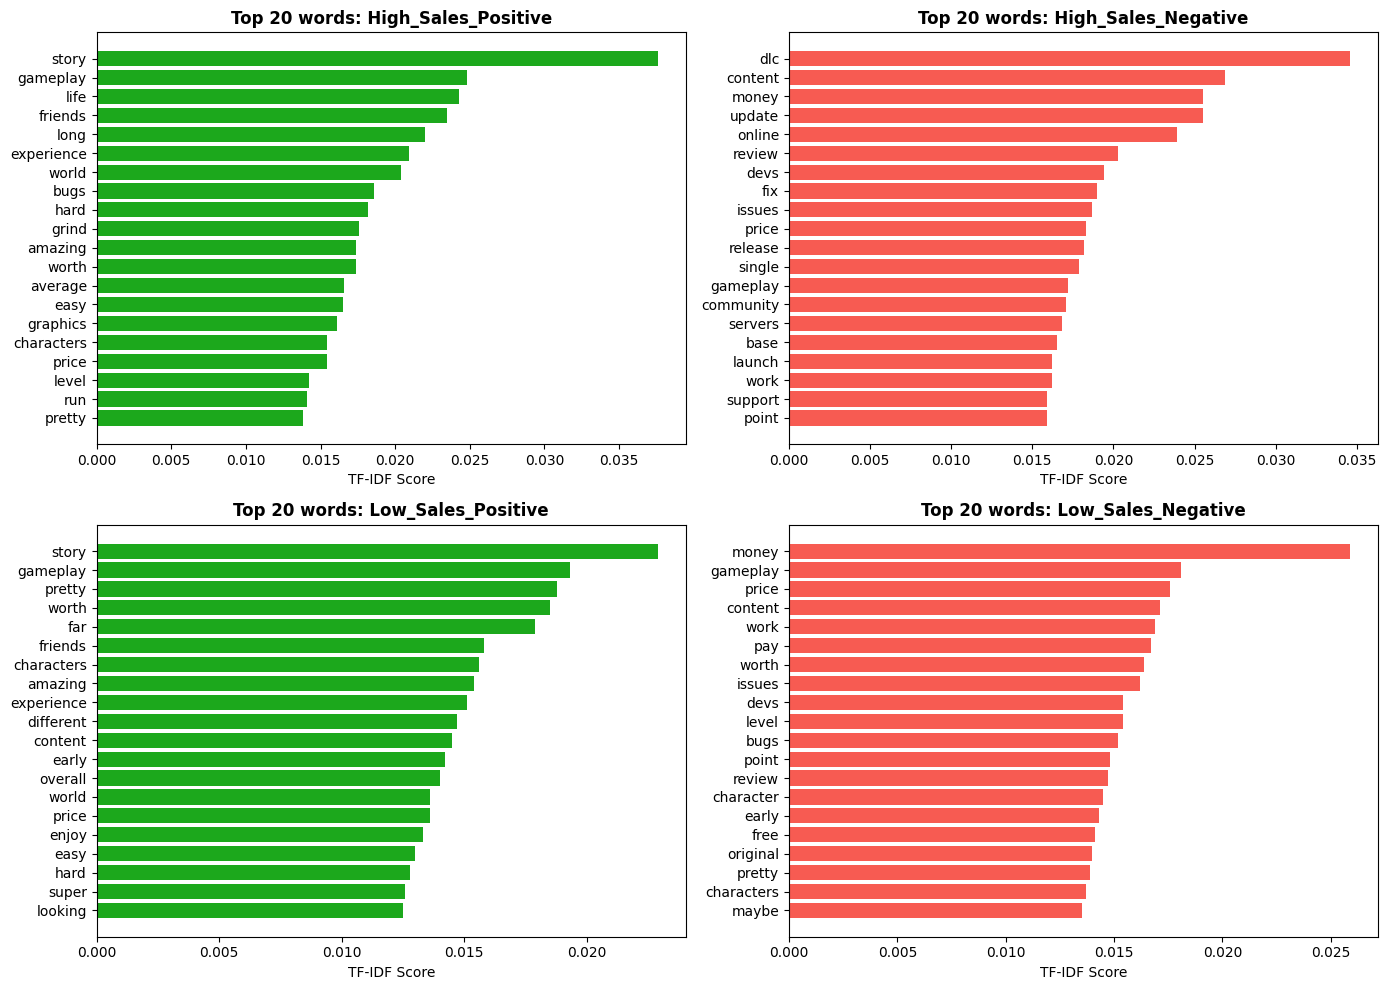

In [20]:
# Visualization 1: create barplots for each subset to represent the TF-IDF score for each words
plt.figure(figsize=(14, 10))

# List of column names to plot
cols = df_comparison.columns

for i, col in enumerate(cols):
    # Create sub-plot for each group
    # each row has two figures and two columns
    plt.subplot(2, 2, i+1)
    
    # Extract data from strings
    words = [x.split(' (')[0] for x in df_comparison[col]][::-1] # Reverse for top-down display
    scores = [float(x.split(' (')[1].replace(')', '')) for x in df_comparison[col]][::-1]

    # make positive as green bar and negative as red bar
    bar_color = "#1ca81c" if 'Positive' in col else "#f75b52"
    
    # Plot the bars horizontally
    plt.barh(words, scores, color=bar_color)
    plt.title(f"Top 20 words: {col}", fontweight='bold')
    plt.xlabel("TF-IDF Score")

# Adjust spacing between charts
plt.tight_layout()
plt.show()

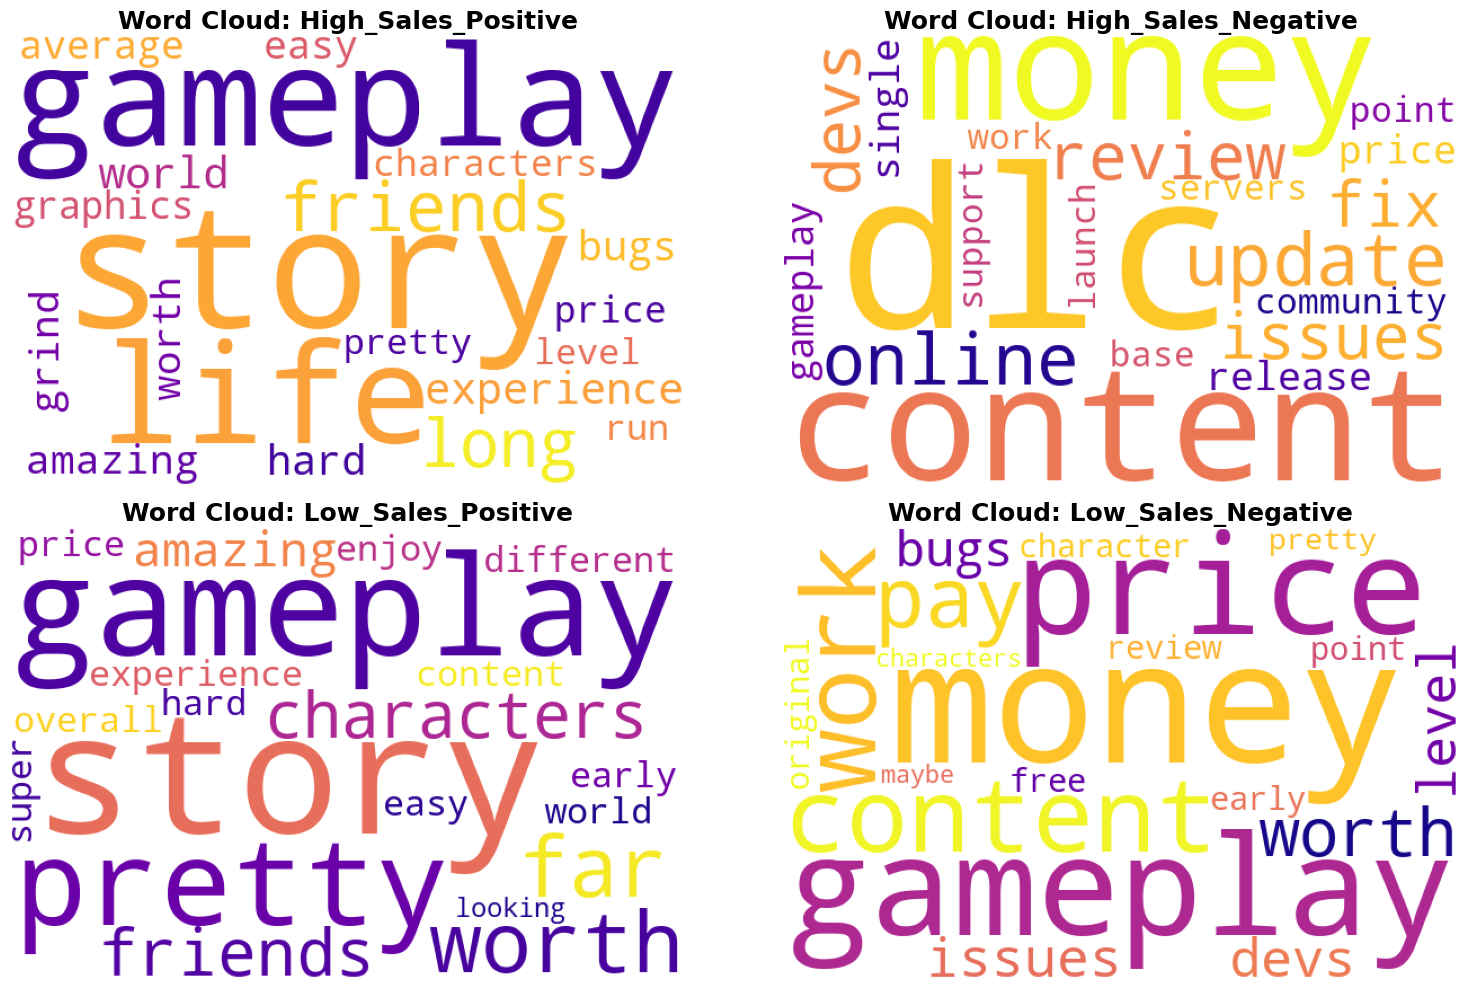

In [22]:
from wordcloud import WordCloud

# Visualization 2: Create word clouds for each subset, larger words represent more weights
plt.figure(figsize=(16, 10))

# Iterate through each column to generate 4 word clouds
for i, col in enumerate(df_comparison.columns):
    # convert "word (0.0123)" into a dictionary, with key is the word, and the value is the score
    # use the value of the words as the cloud size of this word
    word_dict = {}
    for item in df_comparison[col]:
        parts = item.split(' (')
        word = parts[0]
        score = float(parts[1].replace(')', ''))
        word_dict[word] = score

    # create WordCloud based on scores (size of the wordcloud)
    wc = WordCloud(width=600, height=400, background_color='white', colormap='plasma').generate_from_frequencies(word_dict)

    # 3. Plot in the 2x2 grid
    plt.subplot(2, 2, i+1)
    plt.imshow(wc)
    plt.title(f"Word Cloud: {col}", fontsize=18, fontweight='bold')
    plt.axis('off') # Hide axes for more space and clear

plt.tight_layout()
plt.show()

In [ ]:
# Apply TF-IDF (with n-grams, Bigrams to see two-word combinations) on four subset of reviews (Unsupervised Feature Extraction/Text Mining)

# filter out the words that occur more than 80% of the time
# filter out the words that occur less than 10 times
# only get the top 2000 features, top 2000 importance words
tfidf = TfidfVectorizer(max_features=2000, max_df=0.8, min_df=10, stop_words='english', 
                        ngram_range=(1, 2))
tfidf.fit(df['review_clean'])

df_pos_high_tfidf = tfidf.transform(df_pos_high['review_clean'])
df_neg_high_tfidf = tfidf.transform(df_neg_high['review_clean'])
df_pos_low_tfidf = tfidf.transform(df_pos_low['review_clean'])
df_neg_low_tfidf = tfidf.transform(df_neg_low['review_clean'])

# get the top 20 words from each subset
def top_20_words(matrix):
    feature_names = tfidf.get_feature_names_out()
    # calculate the mean TF-IDF score for each feature
    mean_tfidf = matrix.mean(axis=0).tolist()[0]

    # match each feature word with its average TF-IDF score and sort
    word_scores = sorted(zip(feature_names, mean_tfidf), key=lambda x: x[1], reverse=True)
    return [f"{word} ({score:.4f})" for word, score in word_scores[:20]]

top_pos_high = top_20_words(df_pos_high_tfidf)
top_neg_high = top_20_words(df_neg_high_tfidf)
top_pos_low = top_20_words(df_pos_low_tfidf)
top_neg_low = top_20_words(df_neg_low_tfidf)

df_comparison = pd.DataFrame({
    'High_Sales_Positive': top_pos_high,
    'High_Sales_Negative': top_neg_high,
    'Low_Sales_Positive': top_pos_low,
    'Low_Sales_Negative': top_neg_low
})
pd.options.display.float_format = '{:.4f}'.format
print(df_comparison)

# results is same as the one-word, this indicates that the two-word combinations do not significantly change the top words
# so not include this model

    High_Sales_Positive High_Sales_Negative   Low_Sales_Positive  \
0        story (0.0310)        dlc (0.0296)       story (0.0192)   
1     gameplay (0.0201)    content (0.0229)    gameplay (0.0161)   
2      friends (0.0199)     update (0.0211)      pretty (0.0159)   
3         life (0.0193)      money (0.0209)       worth (0.0153)   
4   experience (0.0173)     online (0.0193)         far (0.0151)   
5         long (0.0173)     review (0.0169)     friends (0.0134)   
6        world (0.0169)       devs (0.0162)  characters (0.0131)   
7      amazing (0.0148)        fix (0.0160)     amazing (0.0130)   
8         hard (0.0147)    release (0.0155)  experience (0.0126)   
9         bugs (0.0144)     issues (0.0154)   different (0.0122)   
10       worth (0.0142)    ubisoft (0.0152)     content (0.0122)   
11    graphics (0.0132)      price (0.0151)       early (0.0120)   
12        easy (0.0131)     single (0.0144)     overall (0.0119)   
13  characters (0.0130)   gameplay (0.0143)     

: 